In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

: 

In [6]:
df = pd.read_csv("analysis_dataset.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
# Only these text columns should be merged
text_cols = [
    'inspiration', 
    'what_it_does', 
    'how_we_built_it', 
    'challenges', 
    'accomplishments', 
    'what_we_learned',
    'what_is_next',
    'tech_stack'
]

# Combine selected columns into one text column
df['all_text'] = df[text_cols].astype(str).apply(lambda x: ' '.join(x), axis=1)

# Clean up text (remove 'nan', brackets, double spaces)
df['all_text'] = (
    df['all_text']
    .str.replace(r"\bnan\b", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
# Drop rows with missing values (optional)
df_ml = df.dropna(subset=['github_summary', 'all_text'])
df_ml['text'] = df_ml['github_summary'] + ' ' + df_ml['all_text']
df_ml['label'] = df_ml['is_winner'].astype(int)
df_ml

,hackathon_name,project_name,project_link,is_winner,inspiration,what_it_does,how_we_built_it,challenges,accomplishments,what_we_learned,what_is_next,tech_stack,external_links,github_links,github_summary,all_text,text,label
0,Cal Hacks 10.0,Audiogroph,https://devpost.com/software/audiogroph,False,With covid ending and people finding new music...,"The project shows events, creators and any NFT...",We used react to build it in vscode and collab...,We had to learn react and navigate through git...,We have successfully built the frontend of the...,Start planning earlier and commit to branches ...,We need a backend to our project.,"css3, html5, javascript, react",['https://github.com/RyanGertz/CalHacksproject'],['https://github.com/RyanGertz/CalHacksproject'],"The GitHub repository, ""CalHacksproject,"" is a...",With covid ending and people finding new music...,"The GitHub repository, ""CalHacksproject,"" is a...",0
1,Cal Hacks 10.0,Let It Out,https://devpost.com/software/let-it-out-b2xp8u,False,Understanding and expressing emotions can be a...,The user is first prompted to record a vocal b...,Let It Out is a full stack web app. The front ...,The main challenges we ran into came in our fi...,NaN,We learned how to integrate modern technologie...,NaN,"chakra, flask, hume, mongodb, node.js, openai,...","['https://github.com/apolyeti/calhacks10.0,', ...",['https://github.com/apolyeti/calhacks10.0'],"This repository, named `calhacks10.0`, serves ...",Understanding and expressing emotions can be a...,"This repository, named `calhacks10.0`, serves ...",0
2,Cal Hacks 10.0,Mood Theremin,https://devpost.com/software/mood-theremin,False,"The theremin, an electronic musical instrument...",Mood Theremin translates your facial expressio...,Our project integrates facial expression analy...,NaN,NaN,NaN,NaN,"css, flask, html, hume, javascript, json, pyth...",['https://github.com/Sepulchre49/CalHacks23'],['https://github.com/Sepulchre49/CalHacks23'],The Mood-Theremin repository details a CalHack...,"The theremin, an electronic musical instrument...",The Mood-Theremin repository details a CalHack...,0
3,Cal Hacks 10.0,Bay Area Safer Housing (B.A.S.H.),https://devpost.com/software/bay-area-safer-ho...,False,The inspiration initially stems from one membe...,B.A.S.H. searches for affordable housing optio...,Our website's foundation was built on next.js ...,Our difficulties lay in our inexperience with ...,"Conceptually, we believe that our project is m...",We've learned most importantly how to better a...,We are serious in our project and are intent o...,"catalog.data.gov, data.sfgov.org, google-maps,...","['https://github.com/matthewaol/b.a.s.h.,']",['https://github.com/matthewaol/b.a.s.h.'],b.a.s.h. (Bay Area Safer Housing) is a CalHack...,The inspiration initially stems from one membe...,b.a.s.h. (Bay Area Safer Housing) is a CalHack...,0
4,Cal Hacks 10.0,PawPals,https://devpost.com/software/pawpals-bd8njs,False,"As college students, we both agreed that fun t...","Based on a list of criteria, we prompt OpenAI'...","On the front-end, we utilized Figma to develop...",Some challenges we ran into were the lack of e...,"As a team of two, we were very proud of our fi...",We learned the value of coming up with a plan ...,We hope to deploy the site on Vercel and devel...,"fastapi, figma, openai, python, react.js, sqlite",['https://github.com/Yatsz/PawPals'],['https://github.com/Yatsz/PawPals'],This analysis summarizes the GitHub repository...,"As college students, we both agreed that fun t...",This analysis summarizes the GitHub repository...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1982,VTHacks 12,Real Estate Analyzer,https://devpost.com/software/real-estate-analy...,False,Our project was inspired by the movieThe Big S...,NaN,NaN,NaN,NaN,NaN,NaN,"azure, git, github, placesapi, react, rest, sql",['https://github.com/lakshya46jain/Real-Estate...,['https://github.com/lakshya46jain/Real-Estate...,"This repository, `real_estat

In [ ]:
# Sample 1000 True and 1000 False examples randomly
df_true = df_ml[df_ml['is_winner'] == True].sample(n=1000, random_state=42)
df_false = df_ml[df_ml['is_winner'] == False].sample(n=1000, random_state=42)
df_balanced = pd.concat([df_true, df_false]).sample(frac=1, random_state=42).reset_index(drop=True)
df_balanced['is_winner'].value_counts()

In [10]:
from datasets import ClassLabel, Dataset

# Hugging Face Dataset
dataset = Dataset.from_pandas(df_ml[['text', 'label']])
dataset = dataset.cast_column("label", ClassLabel(num_classes=2))
dataset

Casting the dataset:   0%|          | 0/1987 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 1987
})

In [11]:
# Split into train/test (stratified)
dataset = dataset.train_test_split(test_size=0.2, stratify_by_column='label', seed=42)
train_dataset = dataset['train']
test_dataset = dataset['test']
train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 1589
})

In [12]:
test_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 398
})

In [13]:
model_name = "distilbert-base-uncased"  # smaller, faster BERT variant
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Tell HF which columns to use
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/1589 [00:00<?, ? examples/s]

Map:   0%|          | 0/398 [00:00<?, ? examples/s]

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [15]:
#Model import success

In [16]:
accuracy = evaluate.load("accuracy")
accuracy

EvaluationModule(name: "accuracy", module_type: "metric", features: {'predictions': Value(dtype='int32', id=None), 'references': Value(dtype='int32', id=None)}, usage: """
Args:
    predictions (`list` of `int`): Predicted labels.
    references (`list` of `int`): Ground truth labels.
    normalize (`boolean`): If set to False, returns the number of correctly classified samples. Otherwise, returns the fraction of correctly classified samples. Defaults to True.
    sample_weight (`list` of `float`): Sample weights Defaults to None.

Returns:
    accuracy (`float` or `int`): Accuracy score. Minimum possible value is 0. Maximum possible value is 1.0, or the number of examples input, if `normalize` is set to `True`.. A higher score means higher accuracy.

Examples:

    Example 1-A simple example
        >>> accuracy_metric = evaluate.load("accuracy")
        >>> results = accuracy_metric.compute(references=[0, 1, 2, 0, 1, 2], predictions=[0, 1, 1, 2, 1, 0])
        >>> print(results)
    

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=-1)
    return accuracy.compute(predictions=predictions, references=labels)

In [24]:
training_args = TrainingArguments(
    output_dir="./bert_hackathon_model",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="recall",
    logging_dir="./logs",
    logging_steps=50,
)
training_args

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'gradient_accumulation_kwargs': None},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_steps=None,
evaluation_strategy=IntervalStrategy.EPOCH,
fp16=False,
fp16_backend=auto,
fp16_full_eval=False,
fp16_opt_level=O1,
fsdp=[],
fsdp_config={'min_num_params': 0, 'xla': False, 'xla_fsd

In [25]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)
trainer

In [26]:
results = trainer.evaluate()
print("Test Accuracy:", results["eval_accuracy"])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test Accuracy: 0.21608040201005024


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

           0       1.00      0.04      0.08       325
           1       0.19      1.00      0.32        73

    accuracy                           0.22       398
   macro avg       0.59      0.52      0.20       398
weighted avg       0.85      0.22      0.12       398



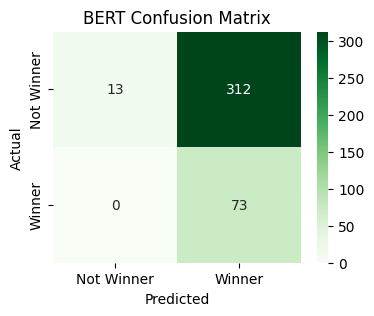

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

preds_output = trainer.predict(test_dataset)
preds = torch.argmax(torch.tensor(preds_output.predictions), axis=-1)
labels = preds_output.label_ids

print(classification_report(labels, preds))

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Not Winner", "Winner"],
            yticklabels=["Not Winner", "Winner"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("BERT Confusion Matrix")
plt.show()
